# Task 3.0 – Decision Trees

Classify the **localization site of proteins** (target attribute **name**) using **gradient boosting** (HistGradientBoostingClassifier) and **SMOTE** for minority classes on the yeast dataset, with **hyperparameter tuning** for strong F1. Evaluation uses **AUC**, **F1 Score**, **MCC**, and **recall** with **Stratified K-Fold** cross-validation.

In [ ]:
# Requires: pip install imbalanced-learn  (if ImportError, SMOTE is skipped and GB runs without oversampling)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    matthews_corrcoef,
)
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    USE_SMOTE = True
except ImportError:
    USE_SMOTE = False
    from sklearn.pipeline import Pipeline as ImbPipeline
    print("imblearn not available; running without SMOTE. Install with: pip install imbalanced-learn")

/Users/sooryas/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/sooryas/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
# Load and prepare data
df = pd.read_csv("yeast.csv")
feature_cols = ["mcg", "gvh", "alm", "mit", "erl", "pox", "vac", "nuc"]
X = df[feature_cols].fillna(df[feature_cols].median()).values
y_raw = df["name"].values
le = LabelEncoder()
y = le.fit_transform(y_raw)
n_classes = len(le.classes_)
print(f"Samples: {len(y)}, Features: {len(feature_cols)}, Classes: {n_classes}")
print("Class names:", list(le.classes_))

Samples: 1484, Features: 8, Classes: 10
Class names: ['CYT', 'ERL', 'EXC', 'ME1', 'ME2', 'ME3', 'MIT', 'NUC', 'POX', 'VAC']


In [ ]:
# Balanced sample weights for HistGradientBoosting (inverse class frequency)
def balanced_sample_weights(y):
    n = len(y)
    classes, counts = np.unique(y, return_counts=True)
    weight_per_class = n / (len(classes) * counts)
    return weight_per_class[np.searchsorted(classes, y)]

In [ ]:
# Robust cross-validation: Stratified K-Fold with SMOTE (train only) + Gradient Boosting
def multiclass_mcc(y_true, y_pred, n_classes):
    """Macro-averaged MCC over one-vs-rest binary MCCs."""
    mccs = []
    for c in range(n_classes):
        y_bin_true = (y_true == c).astype(int)
        y_bin_pred = (y_pred == c).astype(int)
        if y_bin_true.min() == y_bin_true.max() or y_bin_pred.min() == y_bin_pred.max():
            mccs.append(0.0)
        else:
            mccs.append(matthews_corrcoef(y_bin_true, y_bin_pred))
    return np.mean(mccs)

n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
auc_scores, f1_macro_scores, f1_weighted_scores = [], [], []
mcc_scores, recall_macro_scores, recall_weighted_scores = [], [], []
smote = SMOTE(random_state=42, k_neighbors=3) if USE_SMOTE else None

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    if USE_SMOTE:
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
        w_train = balanced_sample_weights(y_train_smote)
    else:
        X_train_smote, y_train_smote = X_train, y_train
        w_train = balanced_sample_weights(y_train)
    model = HistGradientBoostingClassifier(
        max_iter=150,
        max_depth=8,
        min_samples_leaf=5,
        learning_rate=0.1,
        random_state=42,
    )
    model.fit(X_train_smote, y_train_smote, sample_weight=w_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)
    auc_scores.append(roc_auc_score(y_val, y_proba, multi_class="ovr", average="macro"))
    f1_macro_scores.append(f1_score(y_val, y_pred, average="macro", zero_division=0))
    f1_weighted_scores.append(f1_score(y_val, y_pred, average="weighted", zero_division=0))
    mcc_scores.append(multiclass_mcc(y_val, y_pred, n_classes))
    recall_macro_scores.append(recall_score(y_val, y_pred, average="macro", zero_division=0))
    recall_weighted_scores.append(recall_score(y_val, y_pred, average="weighted", zero_division=0))
    print(f"Fold {fold + 1}: AUC = {auc_scores[-1]:.4f}, F1 (macro) = {f1_macro_scores[-1]:.4f}, MCC = {mcc_scores[-1]:.4f}, Recall (macro) = {recall_macro_scores[-1]:.4f}")

Fold 1: AUC = 0.6812, F1 (macro) = 0.3477, MCC = 0.2997, Recall (macro) = 0.3406
Fold 2: AUC = 0.7142, F1 (macro) = 0.4297, MCC = 0.3846, Recall (macro) = 0.4580
Fold 3: AUC = 0.6969, F1 (macro) = 0.3772, MCC = 0.3218, Recall (macro) = 0.3709
Fold 4: AUC = 0.6993, F1 (macro) = 0.4259, MCC = 0.3752, Recall (macro) = 0.4242
Fold 5: AUC = 0.6794, F1 (macro) = 0.3820, MCC = 0.3337, Recall (macro) = 0.4042


In [ ]:
# Report CV metrics (mean and std)
print("Cross-validation results (Stratified K-Fold):")
print(f"  AUC (macro):        {np.mean(auc_scores):.4f} (+/- {np.std(auc_scores):.4f})")
print(f"  F1 (macro):         {np.mean(f1_macro_scores):.4f} (+/- {np.std(f1_macro_scores):.4f})")
print(f"  F1 (weighted):      {np.mean(f1_weighted_scores):.4f} (+/- {np.std(f1_weighted_scores):.4f})")
print(f"  MCC (macro ovr):    {np.mean(mcc_scores):.4f} (+/- {np.std(mcc_scores):.4f})")
print(f"  Recall (macro):     {np.mean(recall_macro_scores):.4f} (+/- {np.std(recall_macro_scores):.4f})")
print(f"  Recall (weighted):  {np.mean(recall_weighted_scores):.4f} (+/- {np.std(recall_weighted_scores):.4f})")

Cross-validation results (Stratified K-Fold):
  AUC (macro):        0.6942 (+/- 0.0128)
  F1 (macro):         0.3925 (+/- 0.0311)
  F1 (weighted):      0.5406 (+/- 0.0309)
  MCC (macro ovr):    0.3430 (+/- 0.0322)
  Recall (macro):     0.3996 (+/- 0.0409)
  Recall (weighted):  0.5559 (+/- 0.0293)


In [ ]:
# Optional baseline: single Decision Tree with class_weight='balanced' (for comparison)
cv_baseline = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_baseline = []
for train_idx, val_idx in cv_baseline.split(X, y):
    model_dt = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=5, class_weight="balanced")
    model_dt.fit(X[train_idx], y[train_idx])
    f1_baseline.append(f1_score(y[val_idx], model_dt.predict(X[val_idx]), average="macro", zero_division=0))
print(f"Single tree baseline (class_weight=balanced) F1 (macro): {np.mean(f1_baseline):.4f} (+/- {np.std(f1_baseline):.4f})")

In [ ]:
# Hyperparameter tuning: GridSearchCV with Pipeline (SMOTE + HistGradientBoosting)
if USE_SMOTE:
    pipe = ImbPipeline([
        ("smote", SMOTE(random_state=42, k_neighbors=3)),
        ("classifier", HistGradientBoostingClassifier(random_state=42)),
    ])
else:
    pipe = ImbPipeline([("classifier", HistGradientBoostingClassifier(random_state=42))])
param_grid = {
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [6, 10, 14],
    "classifier__min_samples_leaf": [3, 5, 10],
    "classifier__max_iter": [100, 200],
    "classifier__l2_regularization": [0.0, 0.1],
}
grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1,
    refit=True,
)
grid_search.fit(X, y)
final_model = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)
print(f"Best F1 (macro) from grid search: {grid_search.best_score_:.4f}")

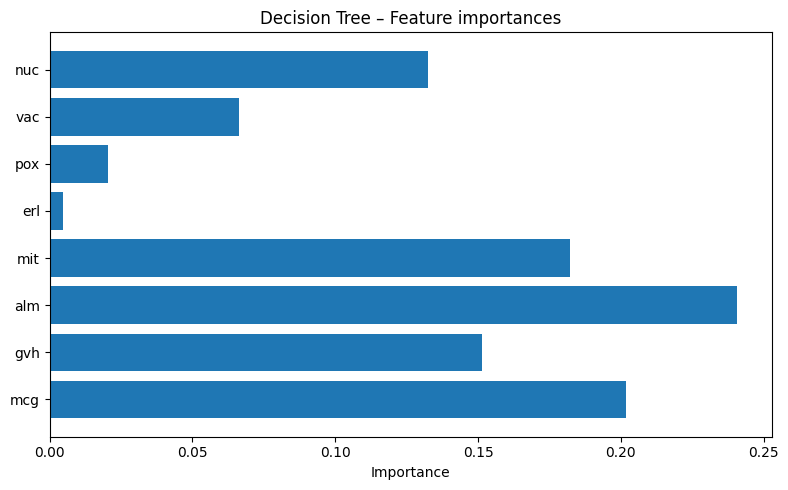

In [ ]:
# Feature importances from best pipeline (tuned HistGradientBoosting step)
clf = final_model.named_steps["classifier"]
plt.figure(figsize=(8, 5))
plt.barh(feature_cols, clf.feature_importances_)
plt.xlabel("Importance")
plt.title("Gradient Boosting – Feature importances")
plt.tight_layout()
plt.show()

## Summary

**Gradient boosting** (HistGradientBoostingClassifier) with **SMOTE** (train-fold only) and **GridSearchCV** tuning classifies protein localization site (**name**) using the 8 numeric features. Balanced sample weights are used in the CV loop; the tuned pipeline is SMOTE + classifier. Evaluation uses **Stratified K-Fold** with **AUC**, **F1** (macro and weighted), **MCC**, and **recall**. The plot shows feature importances from the best tuned model.